# Modern Conversion-Rate Prediction with XGBoost

This notebook modernizes the original conversion-rate project while preserving its two business goals:

1. Predict whether a website session converts.
2. Produce product and marketing insights that can improve conversion.

## What is improved

- Uses **XGBoost** with histogram tree construction and native categorical-feature support.
- Uses separate **training, validation, and test** sets with stratification.
- Uses **early stopping** to control overfitting.
- Treats the roughly 3% conversion target as an imbalanced classification problem.
- Prioritizes **PR-AUC, ROC-AUC, log loss, Brier score, lift, precision, and recall** instead of relying on accuracy.
- Selects a decision threshold on the validation set instead of assuming 0.50 is optimal.
- Keeps probability estimates meaningful by not oversampling the full dataset.
- Includes calibration, lift, feature contribution, segment analysis, and artifact export.
- Explicitly checks whether `total_pages_visited` is available at the intended prediction time.

> The notebook expects the same input file used by the original project: `conversion_data.csv`.

## 0. Environment

Recommended package versions are shown below. Uncomment and run the installation command in a fresh notebook environment.

In [1]:
# %pip install -q "pandas>=2.2" "numpy>=2.0" "scikit-learn>=1.5" \
#     "xgboost>=3.1,<4" "matplotlib>=3.8" "seaborn>=0.13" "nbformat>=5.9"

In [2]:
from __future__ import annotations

import json
import os
import platform
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
import xgboost as xgb

from sklearn.calibration import CalibrationDisplay
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    log_loss,
    precision_recall_curve,
    precision_score,
    recall_score,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    roc_auc_score,
)
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, train_test_split

warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

print({
    "python": platform.python_version(),
    "pandas": pd.__version__,
    "numpy": np.__version__,
    "scikit_learn": sklearn.__version__,
    "xgboost": xgb.__version__,
})

{'python': '3.12.5', 'pandas': '2.2.2', 'numpy': '2.1.0', 'scikit_learn': '1.8.0', 'xgboost': '3.3.0'}


## 1. Configuration

Two prediction modes are supported:

- `session`: includes `total_pages_visited`; suitable only after enough session activity has occurred.
- `acquisition`: excludes `total_pages_visited`; safer for campaign targeting or decisions made before the session unfolds.

Using a feature that is not available at scoring time creates **prediction-time leakage**, even when it improves offline metrics.

In [3]:
DATA_PATH = Path(os.getenv("CONVERSION_DATA_PATH", "conversion_data.csv"))
OUTPUT_DIR = Path("artifacts")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TARGET = "converted"
PREDICTION_MODE = "session"  # Change to "acquisition" for pre-session decisions.
RUN_TUNING = False            # Optional; can take several minutes on the full dataset.

AGE_MIN = 14
AGE_MAX = 100

SESSION_FEATURES = ["country", "age", "new_user", "source", "total_pages_visited"]
ACQUISITION_FEATURES = ["country", "age", "new_user", "source"]
CATEGORICAL_CANDIDATES = ["country", "source"]

if PREDICTION_MODE not in {"session", "acquisition"}:
    raise ValueError("PREDICTION_MODE must be 'session' or 'acquisition'.")

FEATURES = SESSION_FEATURES if PREDICTION_MODE == "session" else ACQUISITION_FEATURES
print("Prediction mode:", PREDICTION_MODE)
print("Features:", FEATURES)

Prediction mode: session
Features: ['country', 'age', 'new_user', 'source', 'total_pages_visited']


## 2. Load and validate the data

In [4]:
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Could not find {DATA_PATH.resolve()}. Place conversion_data.csv next to this "
        "notebook or set the CONVERSION_DATA_PATH environment variable."
    )

raw = pd.read_csv(DATA_PATH)
expected_columns = set(SESSION_FEATURES + [TARGET])
missing_columns = sorted(expected_columns - set(raw.columns))

if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

print(f"Rows: {len(raw):,}")
print(f"Columns: {raw.shape[1]}")
display(raw.head())

Rows: 316,200
Columns: 6


,country,age,new_user,source,total_pages_visited,converted
0,UK,25,1,Ads,1,0
1,US,23,1,Seo,5,0
2,US,28,1,Seo,4,0
3,China,39,1,Seo,5,0
4,US,30,1,Seo,6,0


In [5]:
def data_quality_report(frame: pd.DataFrame) -> pd.DataFrame:
    return pd.DataFrame({
        "dtype": frame.dtypes.astype(str),
        "missing": frame.isna().sum(),
        "missing_pct": frame.isna().mean(),
        "unique": frame.nunique(dropna=False),
    }).sort_values("missing_pct", ascending=False)

print("Exact duplicate rows (not automatically removed):", f"{raw.duplicated().sum():,}")
display(data_quality_report(raw))
display(raw.describe(include="all").T)

Exact duplicate rows (not automatically removed): 299,903


,dtype,missing,missing_pct,unique
country,object,0,0.0000,4
age,int64,0,0.0000,60
new_user,int64,0,0.0000,2
source,object,0,0.0000,3
total_pages_visited,int64,0,0.0000,29
converted,int64,0,0.0000,2


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
country,316200,4,US,178092,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,"316,200.0000",NaN,NaN,NaN,30.5699,8.2718,17.0000,24.0000,30.0000,36.0000,123.0000
new_user,"316,200.0000",NaN,NaN,NaN,0.6855,0.4643,0.0000,0.0000,1.0000,1.0000,1.0000
source,316200,3,Seo,155040,NaN,NaN,NaN,NaN,NaN,NaN,NaN
total_pages_visited,"316,200.0000",NaN,NaN,NaN,4.8730,3.3411,1.0000,2.0000,4.0000,7.0000,29.0000
converted,"316,200.0000",NaN,NaN,NaN,0.0323,0.1767,0.0000,0.0000,0.0000,0.0000,1.0000


### Cleaning rules

The original data contains implausible ages above 100. Here they are treated as invalid records using a transparent, configurable business rule. Exact duplicate feature rows are **not** automatically deleted because multiple anonymous sessions can legitimately share identical values.

In [6]:
df = raw.copy()

# Normalize categorical text.
for column in CATEGORICAL_CANDIDATES:
    df[column] = df[column].astype("string").str.strip().fillna("__MISSING__")

# Coerce numeric fields.
for column in ["age", "new_user", "total_pages_visited", TARGET]:
    df[column] = pd.to_numeric(df[column], errors="coerce")

# Validate target labels.
invalid_target = ~df[TARGET].isin([0, 1])
if invalid_target.any():
    print(f"Dropping {invalid_target.sum():,} rows with missing/invalid target labels.")
    df = df.loc[~invalid_target].copy()

df[TARGET] = df[TARGET].astype("int8")

# Keep missing numeric predictors for XGBoost, but remove impossible ages.
invalid_age = df["age"].notna() & ~df["age"].between(AGE_MIN, AGE_MAX)
print(f"Rows removed by age rule [{AGE_MIN}, {AGE_MAX}]: {invalid_age.sum():,}")
df = df.loc[~invalid_age].reset_index(drop=True)

# Validate new_user when present.
invalid_new_user = df["new_user"].notna() & ~df["new_user"].isin([0, 1])
if invalid_new_user.any():
    raise ValueError(f"Found {invalid_new_user.sum():,} invalid new_user values outside 0/1.")

conversion_rate = df[TARGET].mean()
print(f"Clean rows: {len(df):,}")
print(f"Conversion rate: {conversion_rate:.3%}")
display(df[TARGET].value_counts().rename("rows").to_frame())

Rows removed by age rule [14, 100]: 2
Clean rows: 316,198
Conversion rate: 3.225%


,rows
converted,
0,306000
1,10198


## 3. Exploratory analysis

Segment conversion rates are descriptive, not causal. Differences can reflect user mix, traffic quality, product experience, or confounding variables.

In [7]:
def segment_table(frame: pd.DataFrame, column: str) -> pd.DataFrame:
    table = (
        frame.groupby(column, dropna=False, observed=True)[TARGET]
        .agg(users="size", conversions="sum", conversion_rate="mean")
        .sort_values("conversion_rate", ascending=False)
    )
    table["share_of_traffic"] = table["users"] / len(frame)
    table["lift_vs_overall"] = table["conversion_rate"] / frame[TARGET].mean()
    return table

for column in ["country", "source", "new_user"]:
    print(f"\nConversion by {column}")
    display(segment_table(df, column))


Conversion by country


,users,conversions,conversion_rate,share_of_traffic,lift_vs_overall
country,,,,,
Germany,13055,815,0.0624,0.0413,1.9356
UK,48449,2549,0.0526,0.1532,1.6313
US,178092,6732,0.0378,0.5632,1.1720
China,76602,102,0.0013,0.2423,0.0413



Conversion by source


,users,conversions,conversion_rate,share_of_traffic,lift_vs_overall
source,,,,,
Ads,88739,3059,0.0345,0.2806,1.0688
Seo,155039,5099,0.0329,0.4903,1.0197
Direct,72420,2040,0.0282,0.2290,0.8734



Conversion by new_user


,users,conversions,conversion_rate,share_of_traffic,lift_vs_overall
new_user,,,,,
0,99454,7159,0.0720,0.3145,2.2319
1,216744,3039,0.0140,0.6855,0.4347


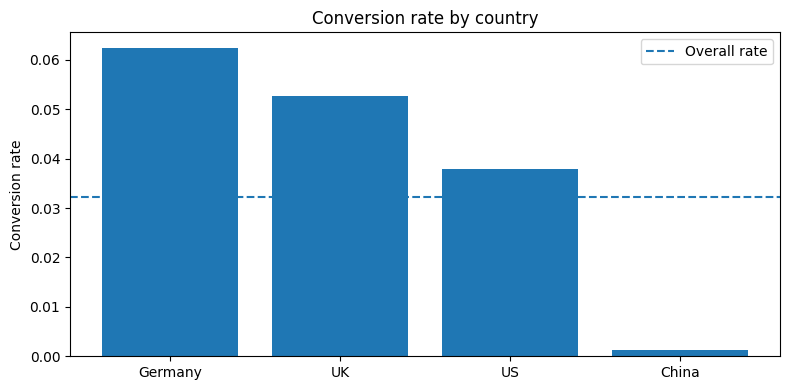

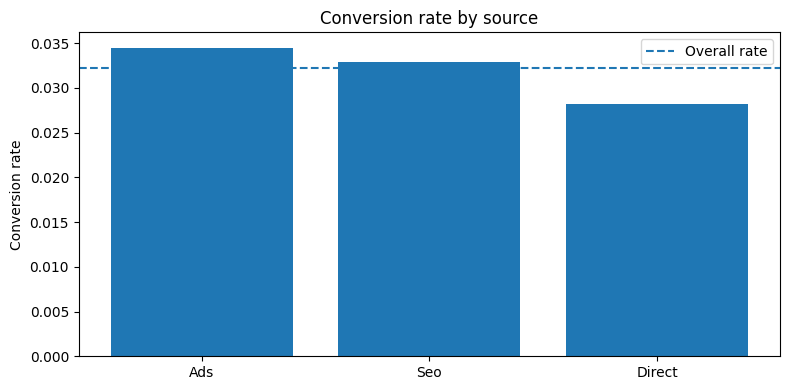

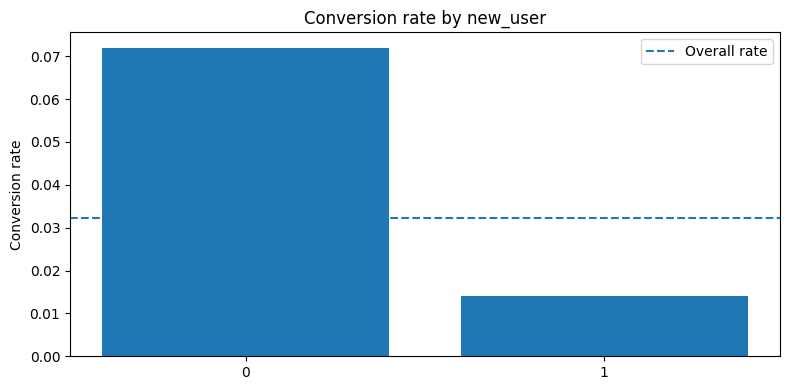

In [8]:
for column in ["country", "source", "new_user"]:
    plot_data = segment_table(df, column).reset_index()
    plt.figure(figsize=(8, 4))
    plt.bar(plot_data[column].astype(str), plot_data["conversion_rate"])
    plt.axhline(df[TARGET].mean(), linestyle="--", label="Overall rate")
    plt.title(f"Conversion rate by {column}")
    plt.ylabel("Conversion rate")
    plt.legend()
    plt.tight_layout()
    plt.show()

,users,conversion_rate
age_band,,
"(13, 20]",35568,0.0627
"(20, 25]",61423,0.0475
"(25, 30]",70860,0.0337
"(30, 35]",63409,0.0234
"(35, 40]",44860,0.0170
"(40, 50]",35355,0.0111
"(50, 65]",4695,0.0049
"(65, 100]",28,0.0000


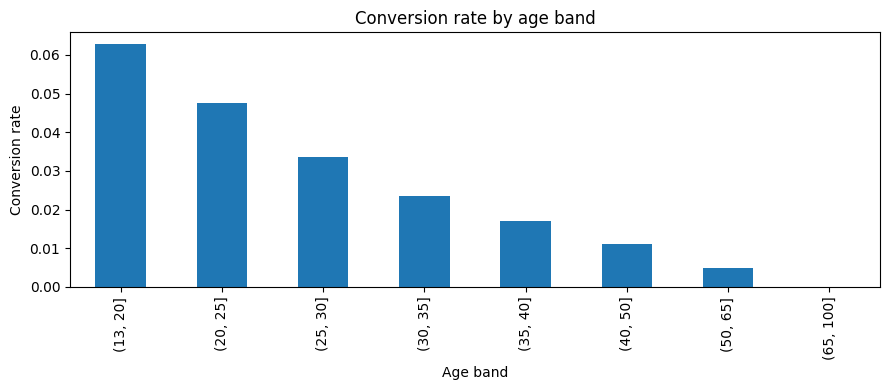

In [9]:
age_bins = pd.cut(df["age"], bins=[13, 20, 25, 30, 35, 40, 50, 65, 100])
age_summary = (
    df.assign(age_band=age_bins)
      .groupby("age_band", observed=True)[TARGET]
      .agg(users="size", conversion_rate="mean")
)
display(age_summary)

plt.figure(figsize=(9, 4))
age_summary["conversion_rate"].plot(kind="bar")
plt.title("Conversion rate by age band")
plt.ylabel("Conversion rate")
plt.xlabel("Age band")
plt.tight_layout()
plt.show()

,total_pages_visited,users,conversion_rate
0,1,40739,0.0000
1,2,43868,0.0002
2,3,43829,0.0003
3,4,41046,0.0008
4,5,36308,0.0016
5,6,30261,0.0034
6,7,23488,0.0068
7,8,17522,0.0152
8,9,12157,0.0331
9,10,8073,0.0611


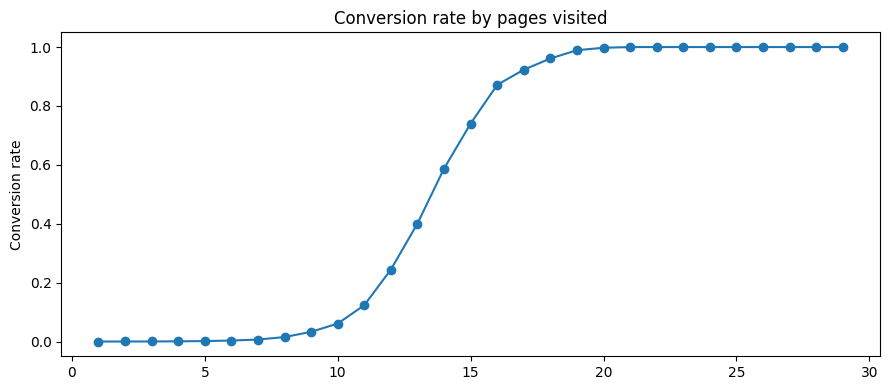

In [10]:
page_summary = (
    df.groupby("total_pages_visited", observed=True)[TARGET]
      .agg(users="size", conversion_rate="mean")
      .reset_index()
)
display(page_summary.head(15))

plt.figure(figsize=(9, 4))
plt.plot(page_summary["total_pages_visited"], page_summary["conversion_rate"], marker="o")
plt.title("Conversion rate by pages visited")
plt.ylabel("Conversion rate")
plt.tight_layout()
plt.show()

## 4. Leakage-safe train/validation/test split

- Training data fits model parameters.
- Validation data controls early stopping and selects the operating threshold.
- Test data is used once for final unbiased evaluation.
- Category levels are learned from training data; unseen values are mapped to `__UNKNOWN__`.

In [11]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df[TARGET],
    random_state=RANDOM_STATE,
)
valid_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df[TARGET],
    random_state=RANDOM_STATE,
)

print({
    "train_rows": len(train_df),
    "validation_rows": len(valid_df),
    "test_rows": len(test_df),
    "train_rate": train_df[TARGET].mean(),
    "validation_rate": valid_df[TARGET].mean(),
    "test_rate": test_df[TARGET].mean(),
})

{'train_rows': 221338, 'validation_rows': 47430, 'test_rows': 47430, 'train_rate': np.float64(0.0322538380214875), 'validation_rate': np.float64(0.03223698081383091), 'test_rate': np.float64(0.03225806451612903)}


In [12]:
def prepare_categorical_splits(
    training: pd.DataFrame,
    validation: pd.DataFrame,
    testing: pd.DataFrame,
    categorical_columns: list[str],
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, dict[str, list[str]]]:
    training = training.copy()
    validation = validation.copy()
    testing = testing.copy()
    category_levels: dict[str, list[str]] = {}

    for column in categorical_columns:
        train_values = training[column].astype("string").fillna("__MISSING__")
        levels = sorted(train_values.dropna().unique().tolist())
        for sentinel in ["__MISSING__", "__UNKNOWN__"]:
            if sentinel not in levels:
                levels.append(sentinel)
        category_levels[column] = levels
        dtype = pd.CategoricalDtype(categories=levels)

        for frame in [training, validation, testing]:
            values = frame[column].astype("string").fillna("__MISSING__")
            values = values.where(values.isin(levels), "__UNKNOWN__")
            frame[column] = values.astype(dtype)

    return training, validation, testing, category_levels

categorical_features = [column for column in CATEGORICAL_CANDIDATES if column in FEATURES]
train_df, valid_df, test_df, category_levels = prepare_categorical_splits(
    train_df, valid_df, test_df, categorical_features
)

X_train, y_train = train_df[FEATURES], train_df[TARGET]
X_valid, y_valid = valid_df[FEATURES], valid_df[TARGET]
X_test, y_test = test_df[FEATURES], test_df[TARGET]

print(X_train.dtypes)

country                category
age                       int64
new_user                  int64
source                 category
total_pages_visited       int64
dtype: object


## 5. Optional hyperparameter search

The search is disabled by default. When enabled, it optimizes average precision with stratified cross-validation. The selected parameters are then retrained with a dedicated validation set and early stopping.

In [13]:
def make_tuning_estimator() -> xgb.XGBClassifier:
    return xgb.XGBClassifier(
        objective="binary:logistic",
        tree_method="hist",
        enable_categorical=True,
        eval_metric="aucpr",
        n_estimators=600,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        max_delta_step=1,
    )

if RUN_TUNING:
    parameter_distributions = {
        "learning_rate": [0.02, 0.04, 0.06, 0.10],
        "max_depth": [3, 4, 5, 6],
        "min_child_weight": [1, 3, 5, 10],
        "subsample": [0.7, 0.85, 1.0],
        "colsample_bytree": [0.7, 0.85, 1.0],
        "reg_alpha": [0.0, 0.1, 0.5, 1.0],
        "reg_lambda": [1.0, 2.0, 5.0, 10.0],
        "gamma": [0.0, 0.1, 0.5],
    }
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
    search = RandomizedSearchCV(
        estimator=make_tuning_estimator(),
        param_distributions=parameter_distributions,
        n_iter=16,
        scoring="average_precision",
        cv=cv,
        random_state=RANDOM_STATE,
        n_jobs=1,  # Let XGBoost parallelize; avoids thread oversubscription.
        verbose=1,
        refit=False,
    )
    search.fit(X_train, y_train)
    best_parameters = search.best_params_
    print("Best cross-validated average precision:", search.best_score_)
    print("Best parameters:", best_parameters)
else:
    best_parameters = {
        "learning_rate": 0.04,
        "max_depth": 4,
        "min_child_weight": 5,
        "subsample": 0.85,
        "colsample_bytree": 0.85,
        "reg_alpha": 0.1,
        "reg_lambda": 3.0,
        "gamma": 0.0,
    }
    print("Using robust default parameters. Set RUN_TUNING=True to search.")

Using robust default parameters. Set RUN_TUNING=True to search.


## 6. Train XGBoost with early stopping

Because the business objective includes conversion probabilities, the default model does **not** oversample or rebalance classes. Rebalancing may improve ranking for some use cases but can distort raw probability estimates unless followed by careful calibration.

In [14]:
early_stopping = xgb.callback.EarlyStopping(
    rounds=100,
    metric_name="logloss",
    data_name="validation_0",
    maximize=False,
    save_best=True,
)

model = xgb.XGBClassifier(
    **best_parameters,
    objective="binary:logistic",
    tree_method="hist",
    enable_categorical=True,
    max_cat_to_onehot=4,
    n_estimators=5_000,
    eval_metric=["logloss", "aucpr"],
    max_delta_step=1,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    callbacks=[early_stopping],
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_valid, y_valid)],
    verbose=100,
)

print("Best iteration:", model.best_iteration)
print("Best validation log loss:", model.best_score)

[0]	validation_0-logloss:0.14036	validation_0-aucpr:0.37981
[100]	validation_0-logloss:0.04883	validation_0-aucpr:0.81431
[200]	validation_0-logloss:0.04214	validation_0-aucpr:0.83591
[300]	validation_0-logloss:0.04190	validation_0-aucpr:0.83670
[400]	validation_0-logloss:0.04188	validation_0-aucpr:0.83668
[423]	validation_0-logloss:0.04189	validation_0-aucpr:0.83660
Best iteration: 324
Best validation log loss: 0.04187844557480819


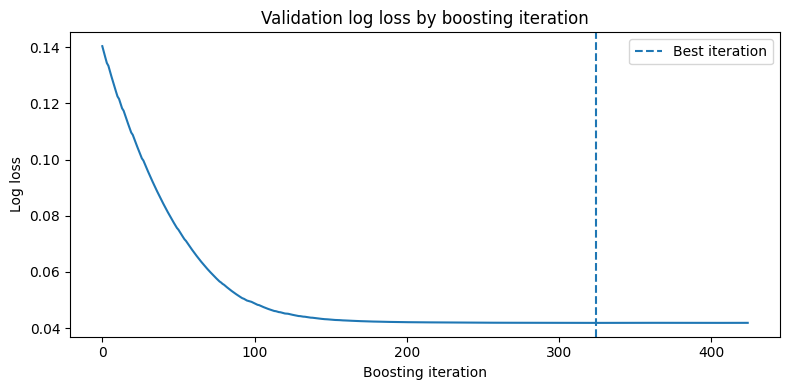

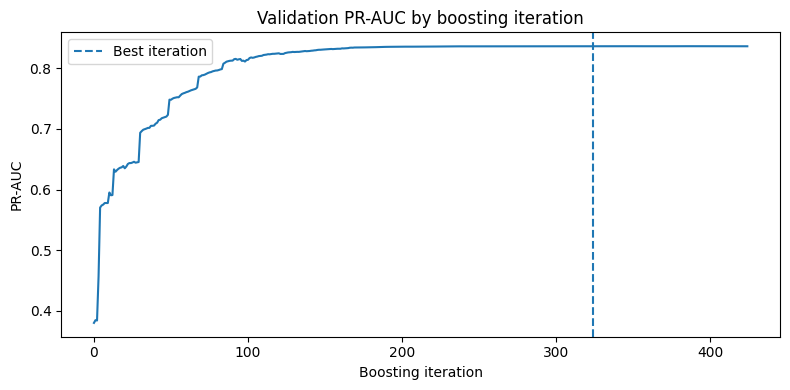

In [15]:
evaluation_history = model.evals_result()["validation_0"]

plt.figure(figsize=(8, 4))
plt.plot(evaluation_history["logloss"])
plt.axvline(model.best_iteration, linestyle="--", label="Best iteration")
plt.title("Validation log loss by boosting iteration")
plt.xlabel("Boosting iteration")
plt.ylabel("Log loss")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(evaluation_history["aucpr"])
plt.axvline(model.best_iteration, linestyle="--", label="Best iteration")
plt.title("Validation PR-AUC by boosting iteration")
plt.xlabel("Boosting iteration")
plt.ylabel("PR-AUC")
plt.legend()
plt.tight_layout()
plt.show()

## 7. Select a decision threshold on validation data

The threshold below maximizes validation F1. In production, replace this with a threshold based on business economics, such as the cost of outreach, expected conversion value, or a required minimum precision/recall.

In [16]:
valid_probability = model.predict_proba(X_valid)[:, 1]
precision_values, recall_values, thresholds = precision_recall_curve(y_valid, valid_probability)

f1_values = 2 * precision_values[:-1] * recall_values[:-1] / np.clip(
    precision_values[:-1] + recall_values[:-1], 1e-12, None
)
best_threshold_index = int(np.nanargmax(f1_values))
selected_threshold = float(thresholds[best_threshold_index])

print({
    "selected_threshold": selected_threshold,
    "validation_precision": float(precision_values[best_threshold_index]),
    "validation_recall": float(recall_values[best_threshold_index]),
    "validation_f1": float(f1_values[best_threshold_index]),
})

{'selected_threshold': 0.40003272891044617, 'validation_precision': 0.8042857142857143, 'validation_recall': 0.736429038587312, 'validation_f1': 0.7688630932058722}


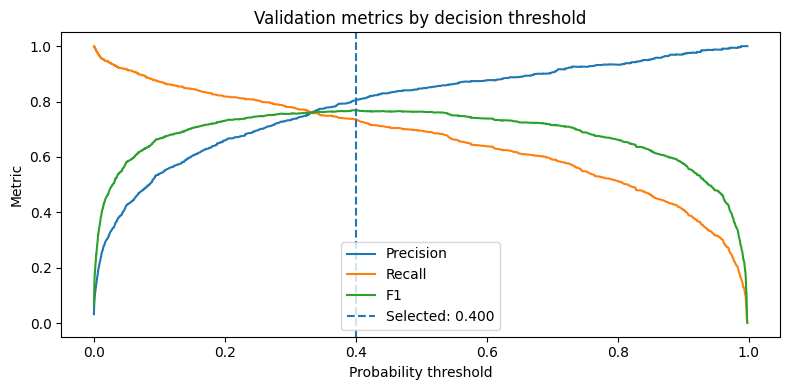

In [17]:
plt.figure(figsize=(8, 4))
plt.plot(thresholds, precision_values[:-1], label="Precision")
plt.plot(thresholds, recall_values[:-1], label="Recall")
plt.plot(thresholds, f1_values, label="F1")
plt.axvline(selected_threshold, linestyle="--", label=f"Selected: {selected_threshold:.3f}")
plt.title("Validation metrics by decision threshold")
plt.xlabel("Probability threshold")
plt.ylabel("Metric")
plt.legend()
plt.tight_layout()
plt.show()

## 8. Final test evaluation

In [18]:
def evaluate_predictions(
    y_true: pd.Series,
    probability: np.ndarray,
    threshold: float,
) -> dict[str, float]:
    prediction = (probability >= threshold).astype(int)
    return {
        "roc_auc": roc_auc_score(y_true, probability),
        "average_precision": average_precision_score(y_true, probability),
        "log_loss": log_loss(y_true, probability),
        "brier_score": brier_score_loss(y_true, probability),
        "accuracy": accuracy_score(y_true, prediction),
        "balanced_accuracy": balanced_accuracy_score(y_true, prediction),
        "precision": precision_score(y_true, prediction, zero_division=0),
        "recall": recall_score(y_true, prediction, zero_division=0),
        "f1": f1_score(y_true, prediction, zero_division=0),
    }

# Prior-probability baseline.
dummy = DummyClassifier(strategy="prior")
dummy.fit(X_train, y_train)
dummy_probability = dummy.predict_proba(X_test)[:, 1]

# XGBoost.
test_probability = model.predict_proba(X_test)[:, 1]
test_prediction = (test_probability >= selected_threshold).astype(int)

metrics_comparison = pd.DataFrame({
    "dummy_prior": evaluate_predictions(y_test, dummy_probability, 0.50),
    "xgboost": evaluate_predictions(y_test, test_probability, selected_threshold),
})
display(metrics_comparison)
print(classification_report(y_test, test_prediction, digits=4, zero_division=0))

,dummy_prior,xgboost
roc_auc,0.5000,0.9868
average_precision,0.0323,0.8490
log_loss,0.1425,0.0398
brier_score,0.0312,0.0106
accuracy,0.9677,0.9859
balanced_accuracy,0.5000,0.8717
precision,0.0000,0.8015
recall,0.0000,0.7497
f1,0.0000,0.7747


              precision    recall  f1-score   support

           0     0.9917    0.9938    0.9927     45900
           1     0.8015    0.7497    0.7747      1530

    accuracy                         0.9859     47430
   macro avg     0.8966    0.8717    0.8837     47430
weighted avg     0.9855    0.9859    0.9857     47430



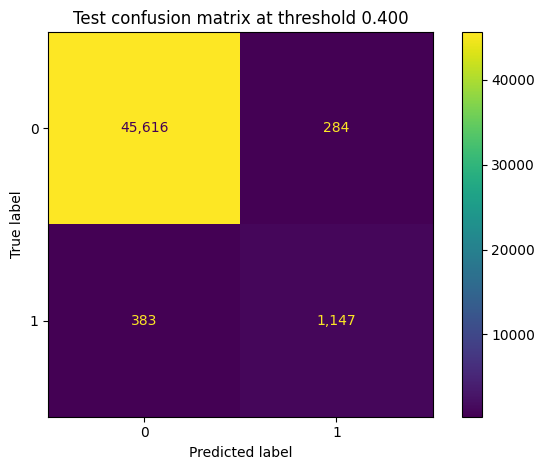

In [19]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_prediction,
    normalize=None,
    values_format=",d",
)
plt.title(f"Test confusion matrix at threshold {selected_threshold:.3f}")
plt.tight_layout()
plt.show()

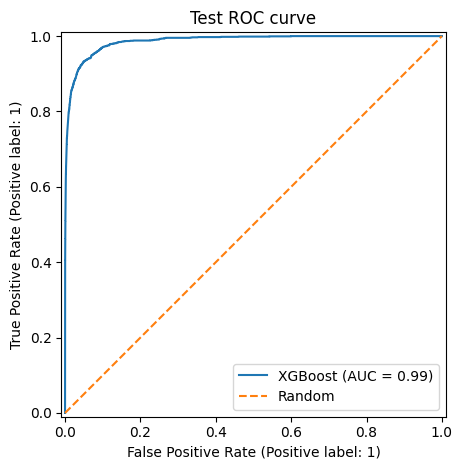

In [20]:
RocCurveDisplay.from_predictions(y_test, test_probability, name="XGBoost")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
plt.title("Test ROC curve")
plt.legend()
plt.tight_layout()
plt.show()

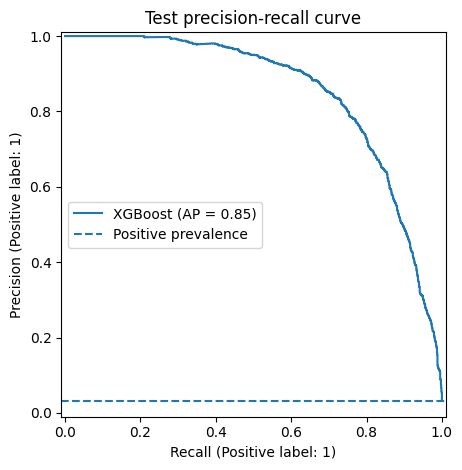

In [21]:
PrecisionRecallDisplay.from_predictions(y_test, test_probability, name="XGBoost")
plt.axhline(y_test.mean(), linestyle="--", label="Positive prevalence")
plt.title("Test precision-recall curve")
plt.legend()
plt.tight_layout()
plt.show()

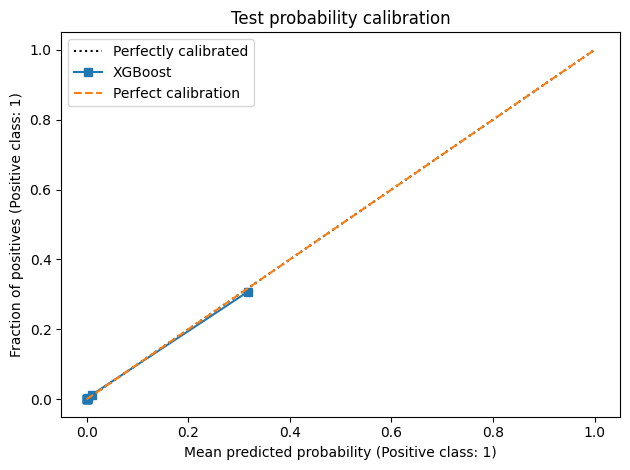

In [22]:
CalibrationDisplay.from_predictions(
    y_test,
    test_probability,
    n_bins=10,
    strategy="quantile",
    name="XGBoost",
)
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
plt.title("Test probability calibration")
plt.legend()
plt.tight_layout()
plt.show()

## 9. Lift and targeting analysis

Lift shows how much better the highest-scored users convert compared with the overall population. This is often more actionable for marketing prioritization than a single classification threshold.

,users,conversions,avg_score,conversion_rate,lift,cumulative_conversion_capture
score_decile,,,,,,
D1,4743,1453,0.3160,0.3063,9.4967,0.9497
D2,4743,58,0.0096,0.0122,0.3791,0.9876
D3,4743,12,0.0030,0.0025,0.0784,0.9954
D4,4743,3,0.0011,0.0006,0.0196,0.9974
D5,4743,2,0.0006,0.0004,0.0131,0.9987
D6,4743,1,0.0003,0.0002,0.0065,0.9993
D7,4743,1,0.0002,0.0002,0.0065,1.0000
D8,4743,0,0.0001,0.0000,0.0000,1.0000
D9,4743,0,0.0001,0.0000,0.0000,1.0000


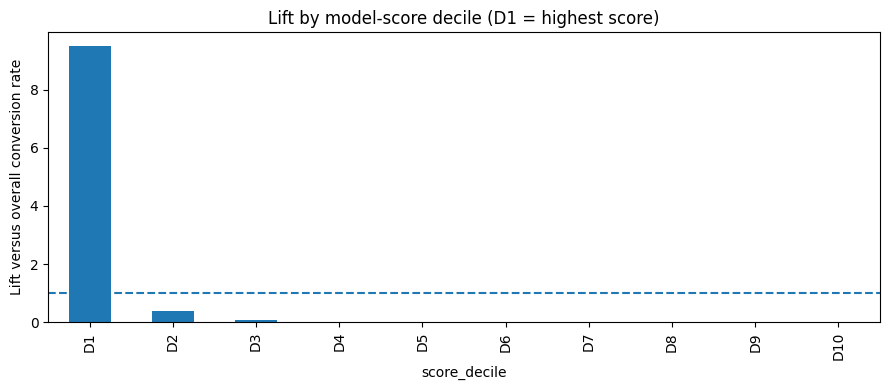

In [23]:
def lift_table(y_true: pd.Series, probability: np.ndarray, bins: int = 10) -> pd.DataFrame:
    scored = pd.DataFrame({"actual": np.asarray(y_true), "probability": probability})
    scored = scored.sort_values("probability", ascending=False).reset_index(drop=True)
    scored["score_decile"] = pd.qcut(
        scored.index,
        q=bins,
        labels=[f"D{i}" for i in range(1, bins + 1)],
    )
    table = (
        scored.groupby("score_decile", observed=True)
        .agg(
            users=("actual", "size"),
            conversions=("actual", "sum"),
            avg_score=("probability", "mean"),
            conversion_rate=("actual", "mean"),
        )
    )
    table["lift"] = table["conversion_rate"] / scored["actual"].mean()
    table["cumulative_conversion_capture"] = table["conversions"].cumsum() / table["conversions"].sum()
    return table

lift = lift_table(y_test, test_probability)
display(lift)

plt.figure(figsize=(9, 4))
lift["lift"].plot(kind="bar")
plt.axhline(1.0, linestyle="--")
plt.title("Lift by model-score decile (D1 = highest score)")
plt.ylabel("Lift versus overall conversion rate")
plt.tight_layout()
plt.show()

## 10. Explain the model

Gain importance shows which features contribute most to tree splits. The following SHAP-contribution calculation uses XGBoost's native `pred_contribs` output and summarizes average absolute contribution on a test sample.

Feature importance is **not causal evidence**. In particular, high importance for pages visited does not prove that forcing users to view more pages will cause conversion.

,feature,gain
0,total_pages_visited,397.6104
1,new_user,69.7428
2,country,29.9442
3,age,10.8430
4,source,2.0956


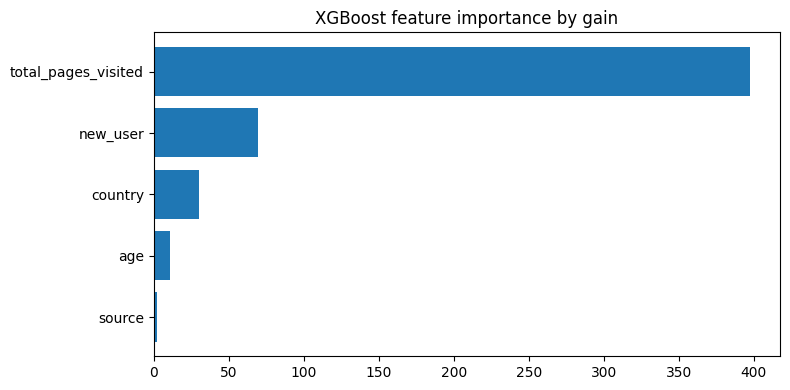

In [24]:
booster = model.get_booster()
gain_scores = booster.get_score(importance_type="gain")
feature_importance = (
    pd.Series(gain_scores, name="gain")
    .sort_values(ascending=False)
    .rename_axis("feature")
    .reset_index()
)
display(feature_importance)

plt.figure(figsize=(8, 4))
plt.barh(feature_importance["feature"].astype(str), feature_importance["gain"])
plt.gca().invert_yaxis()
plt.title("XGBoost feature importance by gain")
plt.tight_layout()
plt.show()

,feature,mean_absolute_contribution
0,total_pages_visited,3.5440
1,new_user,0.7049
2,country,0.6888
3,age,0.4280
4,source,0.0386


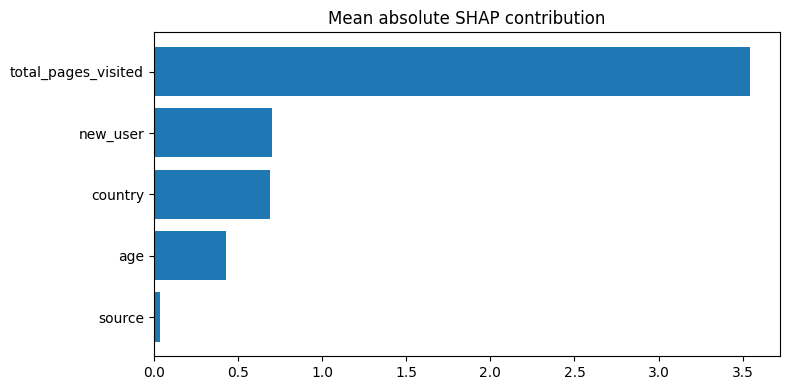

In [25]:
explain_sample = X_test.sample(min(5_000, len(X_test)), random_state=RANDOM_STATE)
explain_matrix = xgb.DMatrix(explain_sample, enable_categorical=True)
contributions = booster.predict(explain_matrix, pred_contribs=True)

# The final column is the bias term.
contribution_summary = (
    pd.Series(
        np.abs(contributions[:, :-1]).mean(axis=0),
        index=FEATURES,
        name="mean_absolute_contribution",
    )
    .sort_values(ascending=False)
    .rename_axis("feature")
    .reset_index()
)
display(contribution_summary)

plt.figure(figsize=(8, 4))
plt.barh(contribution_summary["feature"].astype(str), contribution_summary["mean_absolute_contribution"])
plt.gca().invert_yaxis()
plt.title("Mean absolute SHAP contribution")
plt.tight_layout()
plt.show()

## 11. Product and marketing opportunity tables

These tables combine traffic volume and conversion rate. A low-rate, high-volume segment may represent a larger opportunity than a tiny segment with an extreme rate.

In [26]:
opportunity_tables = {}
for column in ["country", "source", "new_user"]:
    table = segment_table(df, column).copy()
    table["expected_conversions_at_overall_rate"] = table["users"] * df[TARGET].mean()
    table["conversion_gap_vs_overall"] = (
        table["conversions"] - table["expected_conversions_at_overall_rate"]
    )
    opportunity_tables[column] = table
    print(f"\nOpportunity table: {column}")
    display(table.sort_values("conversion_gap_vs_overall"))


Opportunity table: country


,users,conversions,conversion_rate,share_of_traffic,lift_vs_overall,expected_conversions_at_overall_rate,conversion_gap_vs_overall
country,,,,,,,
China,76602,102,0.0013,0.2423,0.0413,"2,470.5634","-2,368.5634"
Germany,13055,815,0.0624,0.0413,1.9356,421.0491,393.9509
UK,48449,2549,0.0526,0.1532,1.6313,"1,562.5744",986.4256
US,178092,6732,0.0378,0.5632,1.1720,"5,743.8131",988.1869



Opportunity table: source


,users,conversions,conversion_rate,share_of_traffic,lift_vs_overall,expected_conversions_at_overall_rate,conversion_gap_vs_overall
source,,,,,,,
Direct,72420,2040,0.0282,0.2290,0.8734,"2,335.6857",-295.6857
Seo,155039,5099,0.0329,0.4903,1.0197,"5,000.3091",98.6909
Ads,88739,3059,0.0345,0.2806,1.0688,"2,862.0052",196.9948



Opportunity table: new_user


,users,conversions,conversion_rate,share_of_traffic,lift_vs_overall,expected_conversions_at_overall_rate,conversion_gap_vs_overall
new_user,,,,,,,
1,216744,3039,0.0140,0.6855,0.4347,"6,990.4152","-3,951.4152"
0,99454,7159,0.0720,0.3145,2.2319,"3,207.5848","3,951.4152"


In [27]:
def print_recommendations() -> None:
    country = opportunity_tables["country"]
    source = opportunity_tables["source"]
    user_type = opportunity_tables["new_user"]

    lowest_country = country["conversion_rate"].idxmin()
    highest_country = country["conversion_rate"].idxmax()
    lowest_source = source["conversion_rate"].idxmin()
    highest_source = source["conversion_rate"].idxmax()

    print("Data-driven hypotheses to test")
    print("-" * 32)
    print(
        f"1. Country experience: {lowest_country} has the lowest observed country rate, "
        f"while {highest_country} has the highest. Audit localization, payment methods, "
        "latency, trust signals, and offer-market fit before changing spend."
    )
    print(
        f"2. Acquisition mix: {lowest_source} has the lowest observed source rate and "
        f"{highest_source} the highest. Compare downstream value and acquisition cost, "
        "not conversion rate alone."
    )
    if 0 in user_type.index and 1 in user_type.index:
        returning_rate = user_type.loc[0, "conversion_rate"]
        new_rate = user_type.loc[1, "conversion_rate"]
        print(
            f"3. User lifecycle: returning-user rate is {returning_rate:.2%}; "
            f"new-user rate is {new_rate:.2%}. Test onboarding, trust, and remarketing "
            "experiences separately."
        )
    if "total_pages_visited" in FEATURES:
        print(
            "4. Session intent: pages visited may be useful for in-session assistance, "
            "but it should not be used for decisions made before those page views occur."
        )
    print(
        "5. Validate every intervention with a randomized experiment; observational "
        "segment differences and model importance do not establish causality."
    )

print_recommendations()

Data-driven hypotheses to test
--------------------------------
1. Country experience: China has the lowest observed country rate, while Germany has the highest. Audit localization, payment methods, latency, trust signals, and offer-market fit before changing spend.
2. Acquisition mix: Direct has the lowest observed source rate and Ads the highest. Compare downstream value and acquisition cost, not conversion rate alone.
3. User lifecycle: returning-user rate is 7.20%; new-user rate is 1.40%. Test onboarding, trust, and remarketing experiences separately.
4. Session intent: pages visited may be useful for in-session assistance, but it should not be used for decisions made before those page views occur.
5. Validate every intervention with a randomized experiment; observational segment differences and model importance do not establish causality.


## 12. Save the model, metadata, and scored test set

Categorical XGBoost models should be serialized in JSON or UBJSON format so categorical information is preserved.

In [28]:
model_path = OUTPUT_DIR / f"conversion_xgboost_{PREDICTION_MODE}.json"
metadata_path = OUTPUT_DIR / f"conversion_xgboost_{PREDICTION_MODE}_metadata.json"
prediction_path = OUTPUT_DIR / f"conversion_xgboost_{PREDICTION_MODE}_test_predictions.csv"

model.save_model(model_path)

metadata = {
    "target": TARGET,
    "prediction_mode": PREDICTION_MODE,
    "features": FEATURES,
    "categorical_features": categorical_features,
    "category_levels": category_levels,
    "selected_threshold": selected_threshold,
    "best_iteration": int(model.best_iteration),
    "test_metrics": {
        key: float(value) for key, value in metrics_comparison["xgboost"].to_dict().items()
    },
    "data_rules": {
        "age_min": AGE_MIN,
        "age_max": AGE_MAX,
    },
    "versions": {
        "pandas": pd.__version__,
        "numpy": np.__version__,
        "scikit_learn": sklearn.__version__,
        "xgboost": xgb.__version__,
    },
}
metadata_path.write_text(json.dumps(metadata, indent=2), encoding="utf-8")

scored_test = test_df.copy()
scored_test["conversion_probability"] = test_probability
scored_test["predicted_conversion"] = test_prediction
scored_test.to_csv(prediction_path, index=False)

print("Saved model:", model_path.resolve())
print("Saved metadata:", metadata_path.resolve())
print("Saved predictions:", prediction_path.resolve())

Saved model: C:\Users\leomi\Desktop\learning\Selflearning\MLE__\Leo_git_repos\Data-Science-Project\01_Conversion Rate\artifacts\conversion_xgboost_session.json
Saved metadata: C:\Users\leomi\Desktop\learning\Selflearning\MLE__\Leo_git_repos\Data-Science-Project\01_Conversion Rate\artifacts\conversion_xgboost_session_metadata.json
Saved predictions: C:\Users\leomi\Desktop\learning\Selflearning\MLE__\Leo_git_repos\Data-Science-Project\01_Conversion Rate\artifacts\conversion_xgboost_session_test_predictions.csv


## Recommended production next steps

1. Define exactly **when** a prediction is made and remove features unavailable at that time.
2. Add campaign cost and conversion value to select a profit-aware threshold.
3. Monitor drift in country, source, age, user mix, score distribution, calibration, and conversion rate.
4. Retrain only after a documented validation check; preserve a time-based holdout when timestamps become available.
5. Use randomized experiments to determine whether proposed product or marketing changes cause conversion improvements.